In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
import random
import os
import environments_fully_observable 
import environments_partially_observable
from agent import Agent
import algorithms.actor_critic as ac
import algorithms.dqn as dqn
import algorithms.random as rn
import algorithms.zigzag as zz
import algorithms.greedy as gr

tf.random.set_seed(0)
random.seed(0)
np.random.seed(0)

2026-03-08 16:00:02.311951: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 16:00:02.318414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772982002.326084   19706 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772982002.328682   19706 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772982002.335223   19706 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
N_BOARDS = 16

GAMMA = 0.9

RESULTS_PATH = "results"
BEST_PARAMS_FOLDER = "best_parameters"
ALG_NAME = "actor_critic_separated_loss_entropy"

In [3]:
def get_env(n=2):
    # n is the number of boards that you want to simulate parallely
    # size is the size of each board, also considering the borders
    # mask for the partially observable, is the size of the local neighborhood
    size = 7
    e = environments_fully_observable.OriginalSnakeEnvironment(n, size)
    # or environments_partially_observable.OriginalSnakeEnvironment(n, size, 2)
    return e
env_ = get_env(n=N_BOARDS)

In [4]:
#ACTOR CRITIC
#logic = ac.create_logic(state_shape=env_.to_state().shape[1:], action_dim=4, n_boards=len(env_.boards), optimizer=None, gamma=GAMMA)
#logic.load_models(folder_path=os.path.join(RESULTS_PATH, "actor_critic_separated_loss_entropy", BEST_PARAMS_FOLDER), state_shape=env_.to_state().shape[1:], load_critic=False)
#agent = Agent(algorithm_logic=logic, algorithm_name="actor_critic_separated_loss_entropy", results_path=RESULTS_PATH, save_frequency=500)

In [5]:
logic = dqn.create_logic(state_shape=env_.to_state().shape[1:], action_dim=4, n_boards=len(env_.boards), optimizer=None, gamma=GAMMA)
logic.load_models(folder_path=os.path.join(RESULTS_PATH, "dqn_9", BEST_PARAMS_FOLDER), state_shape=env_.to_state().shape[1:], train=False)

agent = Agent(algorithm_logic=logic, algorithm_name="dqn_9", results_path=RESULTS_PATH, save_frequency=500)

I0000 00:00:1772982003.426319   19706 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12761 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


DQN Weights loaded successfully.


In [6]:
#RANDOM
#logic = rn.create_logic(state_shape=env_.to_state().shape[1:], action_dim=4, n_boards=env_.n_boards, optimizer=None, gamma=GAMMA)
#agent = Agent(algorithm_logic=logic, algorithm_name="random", algorithm_path=MODELS_PATH, save_frequency=500)

In [7]:
#ZIGZAG
#logic = zz.create_logic(state_shape=env_.to_state().shape[1:], action_dim=4, n_boards=env_.n_boards, optimizer=None, gamma=GAMMA)
#agent = Agent(algorithm_logic=logic, algorithm_name="zigzag", algorithm_path=MODELS_PATH, save_frequency=500)

In [8]:
#GREEDY
#logic = gr.create_logic(state_shape=env_.to_state().shape[1:], action_dim=4, n_boards=env_.n_boards, optimizer=None, gamma=GAMMA)
#agent = Agent(algorithm_logic=logic, algorithm_name="greedy", algorithm_path=MODELS_PATH, save_frequency=500)

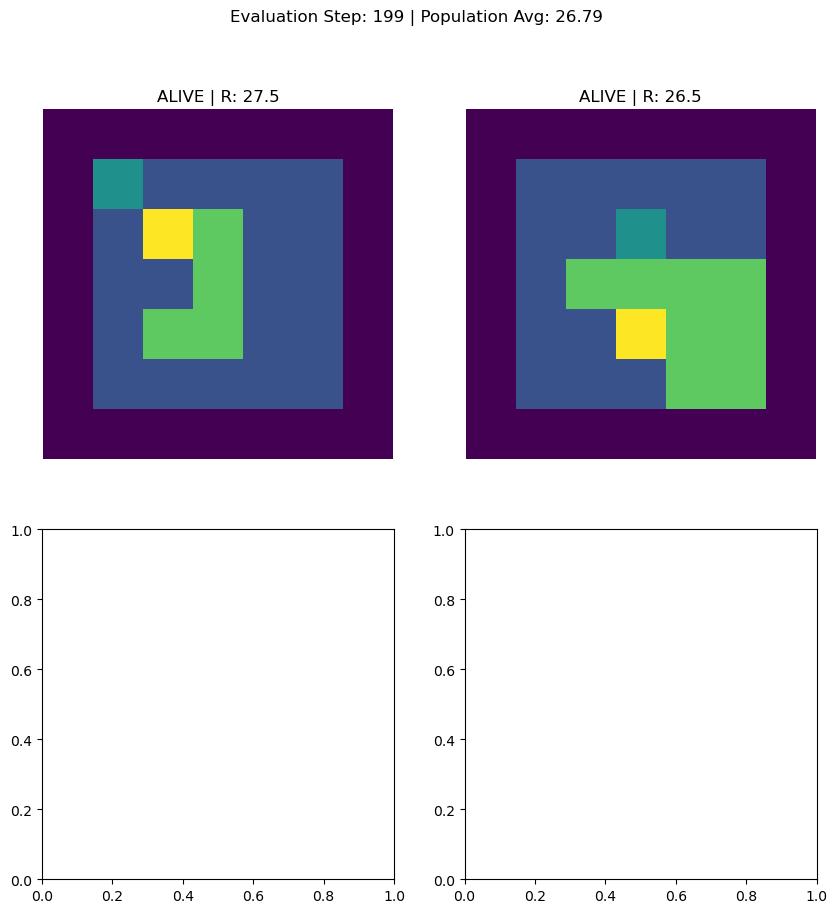

Evaluation data saved to: results/dqn_9/stats/eval_stats.npz


In [9]:
# --- Initialize tracking tensors (shape: N_BOARDS) ---
active_mask = np.ones(N_BOARDS, dtype=np.float32)
cum_rewards = np.zeros(N_BOARDS, dtype=np.float32)
apples_eaten = np.zeros(N_BOARDS, dtype=np.float32)
steps_lived = np.zeros(N_BOARDS, dtype=np.float32)

# --- Evolution arrays (to be plotted) ---
avg_cum_reward_evo = []
avg_apple_ratio_evo = []

max_steps = 200

SHOW_VISUALS = True
PLOT_FREQ = 1
BOARDS_TO_PLOT = min(N_BOARDS, 2)
GRID_DIM = int(np.ceil(np.sqrt(BOARDS_TO_PLOT)))
boards_indices = range(BOARDS_TO_PLOT)


state = tf.cast(env_.to_state(), tf.float32)

for i in range(max_steps):
    actions, _ = agent.get_action(state, training=False)
    
    if len(actions.shape) == 1: 
        actions = tf.expand_dims(actions, axis=-1)

    rewards = env_.move(actions).numpy().flatten()

    # 3. Update Metrics ONLY for active boards
    # We apply the mask so dead boards contribute 0 to the sum and don't increment steps
    cum_rewards += (rewards * active_mask)
    
    # Detect apples: check if reward is 0.5 and board was active
    apples_this_step = ((np.abs(rewards - env_.FRUIT_REWARD) < 1e-3) & (active_mask > 0))
    apples_eaten += apples_this_step.astype(np.float32)
    
    # Increment steps only for those still alive
    steps_lived += active_mask
    
    # 4. Update the Mask (Detect new deaths)
    # A board becomes inactive if it hits a wall (-0.1)
    new_deaths = (np.abs(rewards - env_.HIT_WALL_REWARD) < 1e-3)
    active_mask = active_mask * (1 - new_deaths)

    # 5. CALCULATE STATS FOR THIS STEP (Population Average)
    # Average Cumulative Reward: Mean of all final/current scores
    avg_cum_reward_evo.append(np.mean(cum_rewards))
    
    # Average Apple/Step Ratio: Total Apples / Total Steps taken by all snakes
    total_apples = np.sum(apples_eaten)
    total_steps = np.sum(steps_lived)
    avg_apple_ratio_evo.append(total_apples / total_steps if total_steps > 0 else 0)



    # 2. LIVE PLOTTING
    if SHOW_VISUALS and i % PLOT_FREQ == 0:
        clear_output(wait=True)
        fig, axes = plt.subplots(GRID_DIM, GRID_DIM, figsize=(10, 10))
        axes = axes.flatten()
        
        for t, b_idx in enumerate(boards_indices):
            # Get the board data (shape: size, size)
            board_data = env_.boards[b_idx]
            
            # Use 'origin=lower' because your coordinate system has (1,1) at bottom-left
            axes[t].imshow(board_data, cmap='viridis', origin='lower')
            
            # Status text
            status = "ALIVE" if active_mask[b_idx] > 0 else "DEAD"
            axes[t].set_title(f"{status} | R: {cum_rewards[b_idx]:.1f}")
            axes[t].axis('off')
            
        plt.suptitle(f"Evaluation Step: {i} | Population Avg: {np.mean(cum_rewards):.2f}")
        plt.show()
        
        # Small sleep so human eyes can follow the movement
        time.sleep(0.05)


    # 6. Early exit if all are dead
    if np.sum(active_mask) == 0:
        print(f"All episodes terminated at step {i}")
        break

    
    state = tf.cast(env_.to_state(), tf.float32)
    
# Pass the full evolution to the agent for plotting
agent.record_eval_data(avg_cum_reward_evo, avg_apple_ratio_evo)
agent.save_evaluation_plots()
agent.save_eval_stats_binary(avg_cum_reward_evo, avg_apple_ratio_evo, "eval_stats")

